# Needed Library

ima_takeda is where we put the useful function we created. See ima_takeda.py in this directory.

In [1]:
import ima_takeda as tkd

import pickle
import numpy as np

# Sample: run a single simulation given a set of parameters

In [ ]:
sim_config: dict = dict(
    E_0=500,
    T_0=100,
    r=0.02,
    m=0.02,
    N=100,
    L=1.0,
    k_on=0.2,
    k_off=0.3,
    k_kill=0.02,
    g_E=-0.01,
    g_T=0.0288,
    early_stop=(True, 10, 0.0),
    log_all=True,
    use_tqdm=False,
    seed=21,
)
sim = tkd.WellSimulation(**sim_config)
sim.run()
sim.plot_snapshot()
sim.to_gif("picture/snapshot_tumor_grow.gif")

# Sample: for the same set of parameters, run 1000 times to reveal average behavior and distributions

In [ ]:
monte_carlo, monte_carlo_baseline = tkd.single_scenario_monte_carlo(n_runs=100, sim_kwargs=sim_config)
tkd.plot_result_trend(monte_carlo, use_median=True)
tkd.plot_result_distribution(monte_carlo, step=5, use_violin=True, use_logscale=False)

# Sample: for a same configuration but lists of intial E, T cells, run simulations accordingly

In [13]:
E0_range: np.ndarray = np.linspace(100, 10000, 100, dtype=int)
T0_range: np.ndarray = np.linspace(100, 10000, 100, dtype=int)
# Need to change this. Parameter too unrealistic.
base_kwargs: dict = dict(
    r=0.01,
    m=0.02,
    N=96,
    L=1.0,
    k_on=0.4,
    k_off=0.3,
    k_kill=0.007,
    g_E=0,
    g_T=0.007,
    early_stop=(False, 0, 0.0),
)

# === THIS MAY TAKE A VERY LONG TIME TO RUN!!! I SAVED DATA TO THE PKL FILE SO WE CAN DIRECT READ FROM THERE ===

# grid_F: np.ndarray = tkd.grid_scenario_monte_carlo(E0_range, T0_range, base_kwargs, n_runs=10)
# with open("data/grid_F.pkl", "wb") as f:
#     pickle.dump(grid_F, f)
with open("data/grid_F.pkl", "rb") as f:
    grid_F = pickle.load(f)

## Plot the resulting surface and save to gif

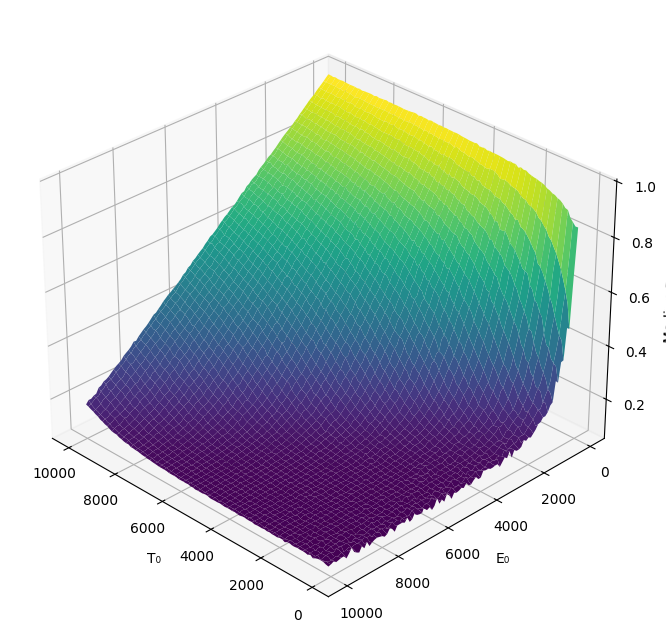

In [14]:
tkd.plot_F_surface_quick(grid_F, E0_range, T0_range)

# tkd.plot_F_surface_gif_quick(
#     grid_F,
#     E0_range,
#     T0_range,
#     use_median=True,
#     n_frames=240,
#     fps=10,
#     save_path="picture/rotating_surface.gif"
# )

## Slice the diagonal for fixed E:T ratio

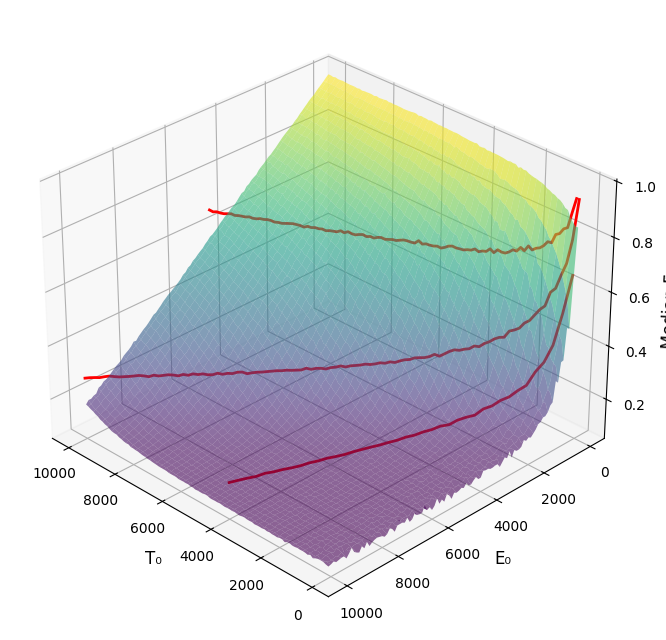

In [4]:
tkd.plot_F_surface_with_ratio_lines(grid_F, E0_range, T0_range, True, [0.5, 1, 2.5])

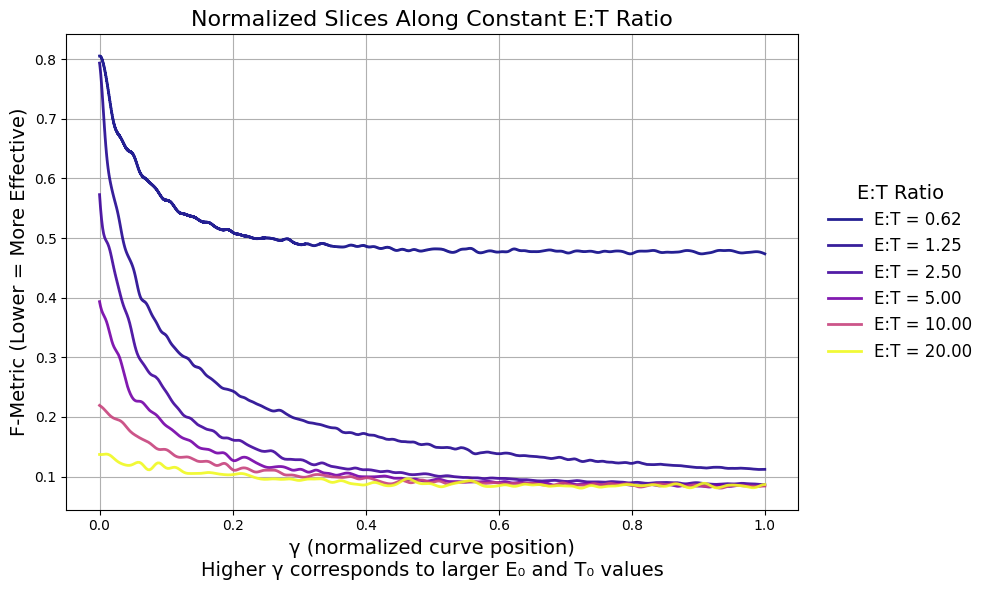

In [15]:
ratio_list: np.ndarray = np.array([0.625, 1.25, 2.5, 5, 10, 20])
tkd.plot_F_diagonal(grid_F=grid_F, E0_range=E0_range, T0_range=T0_range, ratio_list=ratio_list, use_median=True)